In [1]:
# ============================================================
# Level 3 – Task 3: Neural Networks with TensorFlow / Keras
# Codveda Data Science Internship (Advanced Level)
# Dataset: House Prediction Dataset (No Headers)
# ============================================================

# ============================================================
# CELL 1 — Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [4]:
# ============================================================
# CELL 2 — Load Dataset (No Headers)
# ============================================================

# Upload dataset to Colab first

df = pd.read_csv("/content/drive/MyDrive/DATA SET FOR TASK/4) house Prediction Data Set.csv",  sep="\s+", header=None)


print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (506, 14)


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_190/3389119536.py:7: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("/content/drive/MyDrive/DATA SET FOR TASK/4) house Prediction Data Set.csv",  sep="\s+", header=None)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
# ============================================================
# CELL 3 — Add Column Names
# ============================================================

columns = [
"CRIM","ZN","INDUS","CHAS","NOX","RM","AGE",
"DIS","RAD","TAX","PTRATIO","B","LSTAT","MEDV"
]

df.columns = columns

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [6]:
# ============================================================
# CELL 4 — Check Dataset Information
# ============================================================

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695   

In [7]:

# ============================================================
# CELL 5 — Separate Features and Target
# ============================================================

X = df.drop("MEDV", axis=1)
y = df["MEDV"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (506, 13)
Target Shape: (506,)


In [8]:
# ============================================================
# CELL 6 — Feature Scaling
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [9]:


# ============================================================
# CELL 7 — Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)


Training Samples: (404, 13)
Testing Samples: (102, 13)


In [10]:
# ============================================================
# CELL 8 — Build Neural Network Model
# ============================================================

model = keras.Sequential([

    layers.Dense(64, activation='relu', input_shape=(13,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),

    layers.Dense(1)

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:




# ============================================================
# CELL 9 — Compile Model
# ============================================================

model.compile(

    optimizer='adam',
    loss='mse',
    metrics=['mae']

)

In [12]:
# ============================================================
# CELL 10 — Train Model
# ============================================================

history = model.fit(

    X_train,
    y_train,

    epochs=100,
    batch_size=16,

    validation_split=0.2,

    verbose=1

)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 639.9869 - mae: 23.2801 - val_loss: 537.7977 - val_mae: 21.6532
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 627.3109 - mae: 22.9925 - val_loss: 473.1195 - val_mae: 20.1142
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 492.7849 - mae: 20.1365 - val_loss: 357.2964 - val_mae: 17.1241
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 353.5273 - mae: 16.5659 - val_loss: 184.4412 - val_mae: 11.6152
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 177.1231 - mae: 11.0134 - val_loss: 68.7621 - val_mae: 5.9991
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 77.2306 - mae: 6.8223 - val_loss: 40.2129 - val_mae: 4.3776
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 53.2212 - mae: 5.4669 - val_loss: 29.8930 - val_mae: 3.6452
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 30.9666 - mae: 3.9985 - val_loss: 27.6093 - val_mae: 3.5915
Epoch 9/100
21/21 ━━━━━━━━━━━

In [13]:
# ============================================================
# CELL 11 — Evaluate Model
# ============================================================

loss, mae = model.evaluate(X_test, y_test)

print("\nTest Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.1643 - mae: 2.1212

Test Loss (MSE): 11.94630241394043
Test MAE: 2.2667901515960693


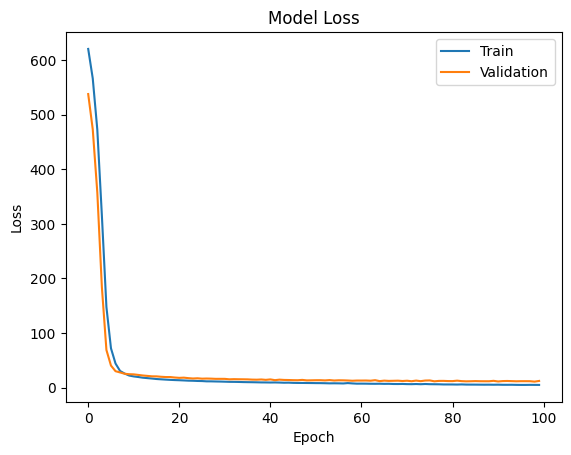

In [14]:
# ============================================================
# CELL 12 — Plot Training Loss
# ============================================================

plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()

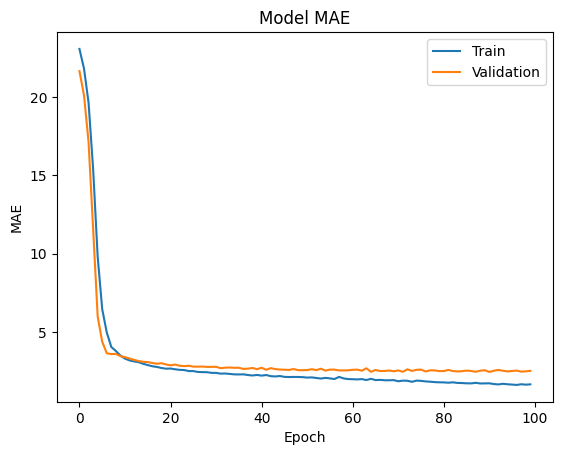

In [15]:


# ============================================================
# CELL 13 — Plot Mean Absolute Error
# ============================================================

plt.figure()

plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])

plt.title("Model MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")

plt.legend(["Train", "Validation"])

plt.show()

In [ ]:
# ============================================================
# CELL 14 — INTERPRETATION
# ============================================================


# INTERPRETATION

# 1. The neural network learns relationships between housing
  #  features such as crime rate, number of rooms, tax rate, and house prices.

# 2. The model uses 13 input features and predicts MEDV, which represents the median house value.

# 3. ReLU activation allows the model to capture nonlinear  relationships between the housing variables.

# 4. Mean Squared Error (MSE) measures how far predicted  prices are from the true house prices.

# 5. Mean Absolute Error (MAE) represents the average  difference between predicted and actual house prices.

# 6. The training and validation curves help detect overfitting or underfitting.


